In [114]:
import os

def list_subdirectories(flux_dir):
    return [
        name for name in os.listdir(flux_dir)
        if os.path.isdir(os.path.join(flux_dir, name)) and 'logs' not in name
    ]

def list_subdirectories2(filtered_flux_dir):
    return [
        name.removeprefix('filtered_') for name in os.listdir(filtered_flux_dir)
        if os.path.isdir(os.path.join(filtered_flux_dir, name)) and 'logs' not in name
    ]


# Get the set of subdirectories present in both lists
def get_concurrent_subdirectories(flux_dir, filtered_flux_dir):
    subdirs1 = set(list_subdirectories(flux_dir))
    subdirs2 = set(list_subdirectories2(filtered_flux_dir))
    return list(subdirs1 & subdirs2)


In [115]:

flux_results_path = '/data3/jhpark/artifacts_100'
filtered_flux_results_path = '/data3/jhpark/filtered_artifacts_100'
flux_results_dirs = list_subdirectories(flux_results_path)
filtered_flux_results_dirs = list_subdirectories2(filtered_flux_results_path)

exp_dirs = get_concurrent_subdirectories(flux_results_path, filtered_flux_results_path)


In [116]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def plot_comparison_png(parent_dir, subdirectory):
    comparison_path = os.path.join(parent_dir, subdirectory, "comparison.png")
    img = mpimg.imread(comparison_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{subdirectory}/comparison.png")
    plt.show()


In [117]:
def plot_filtered_metadata(parent_dir, subdirectory):
    metadata_path = os.path.join(parent_dir, f"filtered_{subdirectory}", "metadata.json")
    import json

    with open(metadata_path, 'r') as f:
        metadata = json.load(f)

    artifact_image_path = os.path.join(parent_dir, f"filtered_{subdirectory}", "artifact_image.png")
    img = mpimg.imread(artifact_image_path)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')

    for artifact in metadata:
        bbox = artifact['target_bbox']
        x1, y1, x2, y2 = bbox
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='r', facecolor='none')
        plt.gca().add_patch(rect)
    plt.show()

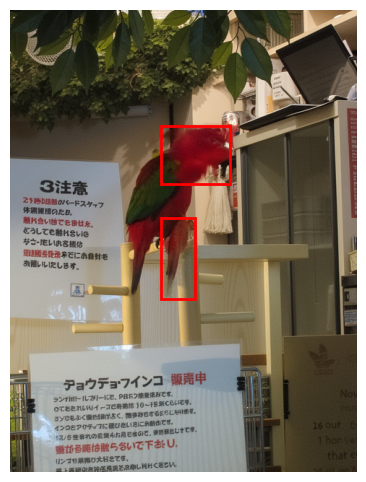

In [118]:
plot_filtered_metadata(filtered_flux_results_path, flux_result)

In [119]:
flux_results_iter = iter(exp_dirs)

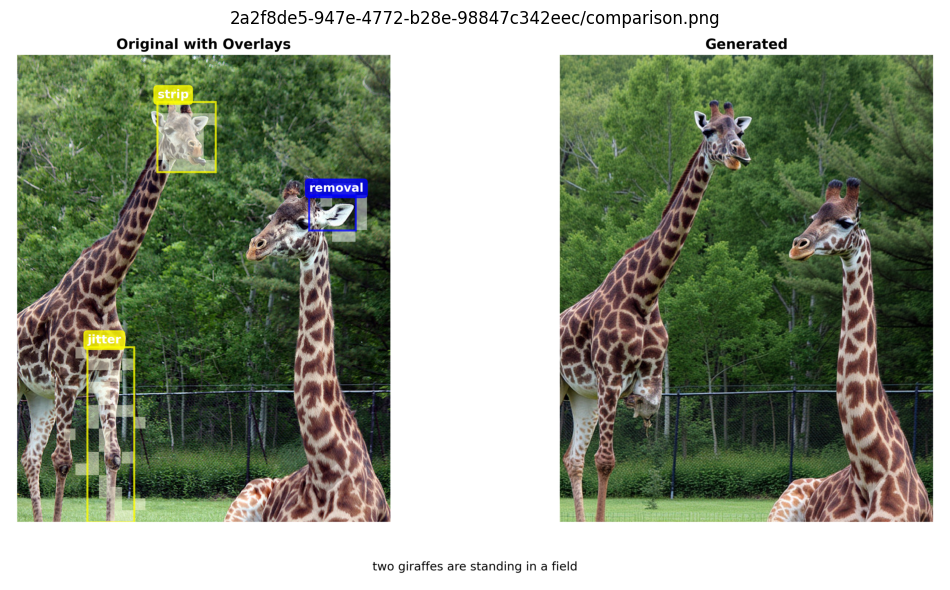

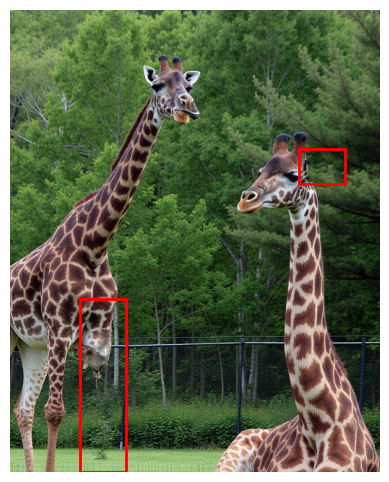

In [165]:
flux_result = next(flux_results_iter)
plot_comparison_png(flux_results_path, flux_result)
plot_filtered_metadata(filtered_flux_results_path, flux_result)